# Linearization Utility

Use this notebook to define the X-maze graph directly in the NWB position coordinate system. The trajectory is already stored in centimeters, so we should click on the trajectory itself rather than on an image in pixel coordinates.

## 0. Setup

This notebook streams one NWB file, plots the 2D trajectory in centimeters, and lets you click candidate node locations while reading off their `(x, y)` coordinates.

In [1]:
%matplotlib widget
%config InlineBackend.figure_format = 'retina'

import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from dandi.dandiapi import DandiAPIClient
import remfile
from h5py import File
from pynwb import NWBHDF5IO
from track_linearization import make_track_graph, plot_graph_as_1D, plot_track_graph

warnings.filterwarnings('ignore', category=UserWarning)

sns.set_theme(
    context='notebook',
    style='ticks',
    rc={
        'figure.dpi': 120,
        'savefig.dpi': 300,
        'axes.spines.top': False,
        'axes.spines.right': False,
    },
)


## 1. Stream one session

Use the same session you plan to decode. The position coordinates in this dataset are already in centimeters.

In [2]:
DANDISET_ID = "001701"
DANDISET_VERSION = "0.260120.0303"
# asset_path = "sub-Lamarr/sub-Lamarr_ses-Lamarr-DY01-g0_behavior+ecephys.nwb"
asset_path = "sub-Lovelace/sub-Lovelace_ses-Lovelace-DY01-g1_behavior+ecephys.nwb"




In [3]:
client = DandiAPIClient()
dandiset = client.get_dandiset(DANDISET_ID, DANDISET_VERSION)
asset = dandiset.get_asset_by_path(asset_path)
stream_url = asset.get_content_url(follow_redirects=1, strip_query=True)

remote_file = File(remfile.File(stream_url), 'r')
io = NWBHDF5IO(file=remote_file, mode='r', load_namespaces=True)
nwb = io.read()

print('Streaming NWB file:')
print(asset.path)
print('\nSession description:', nwb.session_description)
print('Identifier:', nwb.identifier)


A newer version (0.76.6) of dandi/dandi-cli is available. You are using 0.76.5


Streaming NWB file:
sub-Lovelace/sub-Lovelace_ses-Lovelace-DY01-g1_behavior+ecephys.nwb

Session description: X Maze
Identifier: AeryJones,EmilyLovelaceDY01-g1


## 2. Extract 2D position

We use the NWB trajectory directly. No pixel-to-cm conversion is needed here.

In [4]:
position_series = nwb.processing['behavior']['Position']['position']
position_data = position_series.data[:]
sampling_rate = position_series.rate
series_start_time = position_series.starting_time

time = series_start_time + np.arange(position_data.shape[0]) / sampling_rate
x = position_data[:, 0]
y = position_data[:, 1]

valid = np.isfinite(x) & np.isfinite(y) & np.isfinite(time)
position_df = pd.DataFrame({
    'time': time[valid],
    'x': x[valid],
    'y': y[valid],
}).reset_index(drop=True)

print('Position unit:', position_series.unit)
print('Reference frame:', position_series.reference_frame)
print('x range:', position_df['x'].min(), position_df['x'].max())
print('y range:', position_df['y'].min(), position_df['y'].max())


Position unit: centimeters
Reference frame: (0,0) is bottom left corner
x range: 5.796082468105275 80.20890603289963
y range: 7.568744948333833 97.4042375934025


## 3. Plot the trajectory with dense axes

This plot is in maze coordinates. The ticks are intentionally dense so you can read off approximate node positions before clicking.

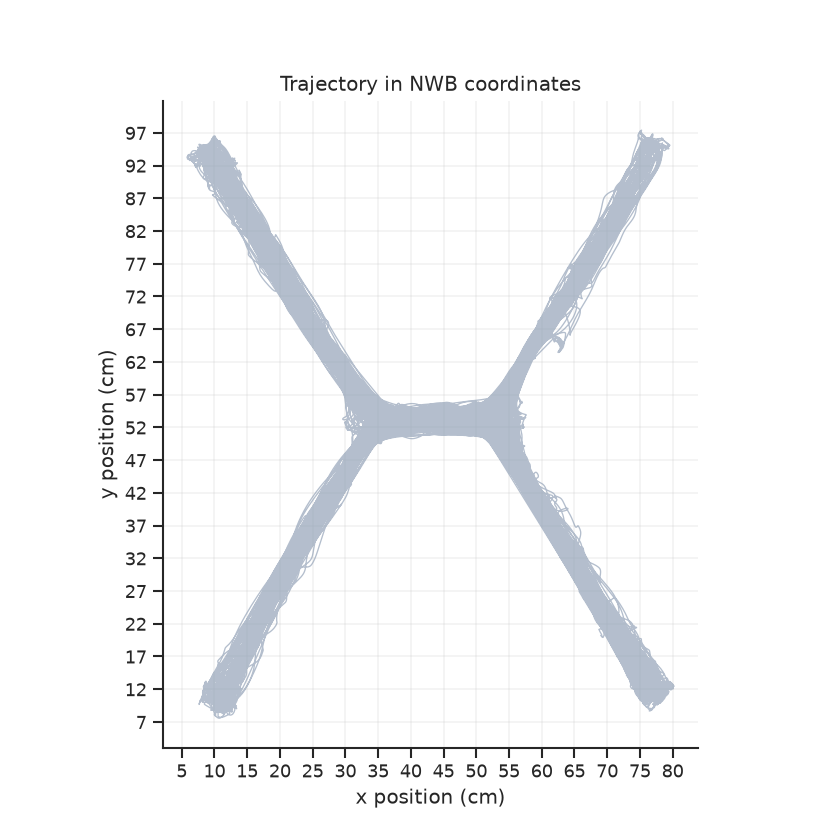

In [5]:
x_min, x_max = position_df['x'].min(), position_df['x'].max()
y_min, y_max = position_df['y'].min(), position_df['y'].max()

fig, ax = plt.subplots(figsize=(7, 7))
ax.plot(position_df['x'], position_df['y'], color='#94a3b8', linewidth=0.8, alpha=0.7)
ax.set_aspect('equal', adjustable='box')
ax.set_xlabel('x position (cm)')
ax.set_ylabel('y position (cm)')
ax.set_title('Trajectory in NWB coordinates')

ax.set_xticks(np.arange(np.floor(x_min), np.ceil(x_max) + 1, 5))
ax.set_yticks(np.arange(np.floor(y_min), np.ceil(y_max) + 1, 5))
ax.grid(True, alpha=0.25)
plt.show()


## 4. Click candidate node positions

Click on the trajectory to read out node coordinates in centimeters. Each click adds a labeled point and appends its coordinates to `clicked_points`. Use those values to build `node_positions` in the next section.

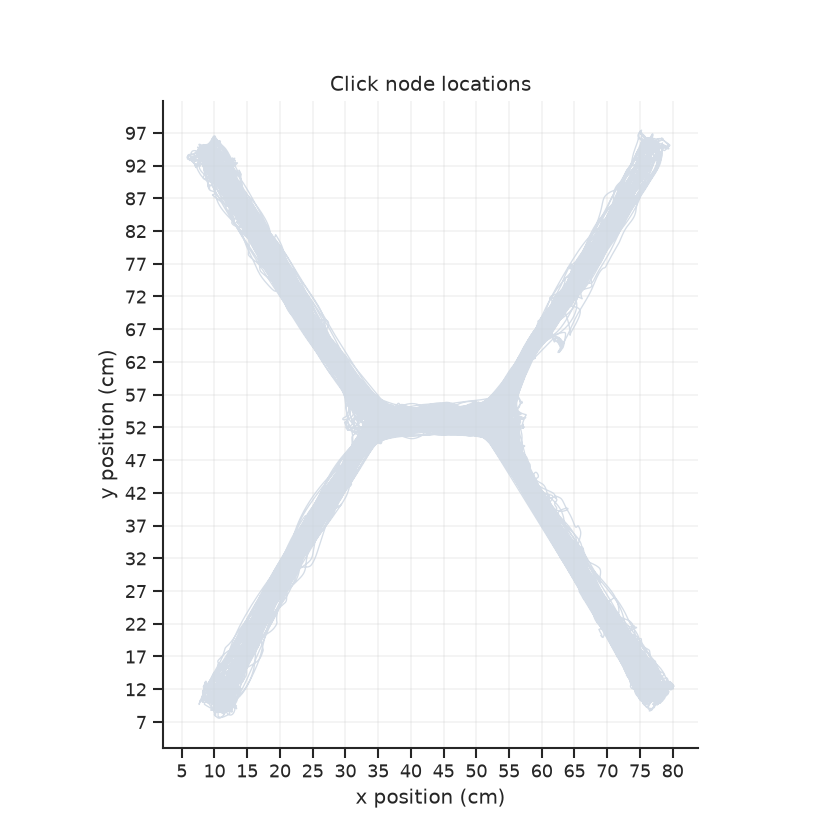

In [7]:
clicked_points = []

fig, ax = plt.subplots(figsize=(7, 7))
ax.plot(position_df['x'], position_df['y'], color='#cbd5e1', linewidth=0.8, alpha=0.8)
ax.set_aspect('equal', adjustable='box')
ax.set_xlabel('x position (cm)')
ax.set_ylabel('y position (cm)')
ax.set_title('Click node locations')
ax.set_xticks(np.arange(np.floor(x_min), np.ceil(x_max) + 1, 5))
ax.set_yticks(np.arange(np.floor(y_min), np.ceil(y_max) + 1, 5))
ax.grid(True, alpha=0.25)


def on_click(event):
    if event.inaxes != ax or event.xdata is None or event.ydata is None:
        return

    x_click = float(event.xdata)
    y_click = float(event.ydata)
    clicked_points.append((x_click, y_click))
    point_i = len(clicked_points) - 1

    ax.scatter([x_click], [y_click], s=60, color='#2563eb', zorder=5)
    ax.text(x_click + 0.6, y_click + 0.6, str(point_i), color='#1f2937', fontsize=10)
    fig.canvas.draw_idle()

    print(f'{point_i}: ({x_click:.2f}, {y_click:.2f})')


cid = fig.canvas.mpl_connect('button_press_event', on_click)
plt.show()


In [8]:
clicked_points


[(7.6634286847266715, 95.10845758498512),
 (33.636275197756724, 53.399121714060385),
 (9.344024635569795, 9.39806409198594),
 (52.42839355718435, 53.704684614213676),
 (76.87342556944793, 96.63627208575159),
 (78.24845862013775, 10.620315692599121)]

## 5. Define the graph

Use the clicked coordinates to build `node_positions`. Keep the coordinates in centimeters. Then define the edge list by node index.

In [10]:
node_positions = [(7.6634286847266715, 95.10845758498512),
 (33.636275197756724, 53.399121714060385),
 (9.344024635569795, 9.39806409198594),
 (52.42839355718435, 53.704684614213676),
 (76.87342556944793, 96.63627208575159),
 (78.24845862013775, 10.620315692599121)]

edges = [
    (0, 1),
    (1, 2),
    (1, 3),
    (3, 4),
    (3, 5),
]

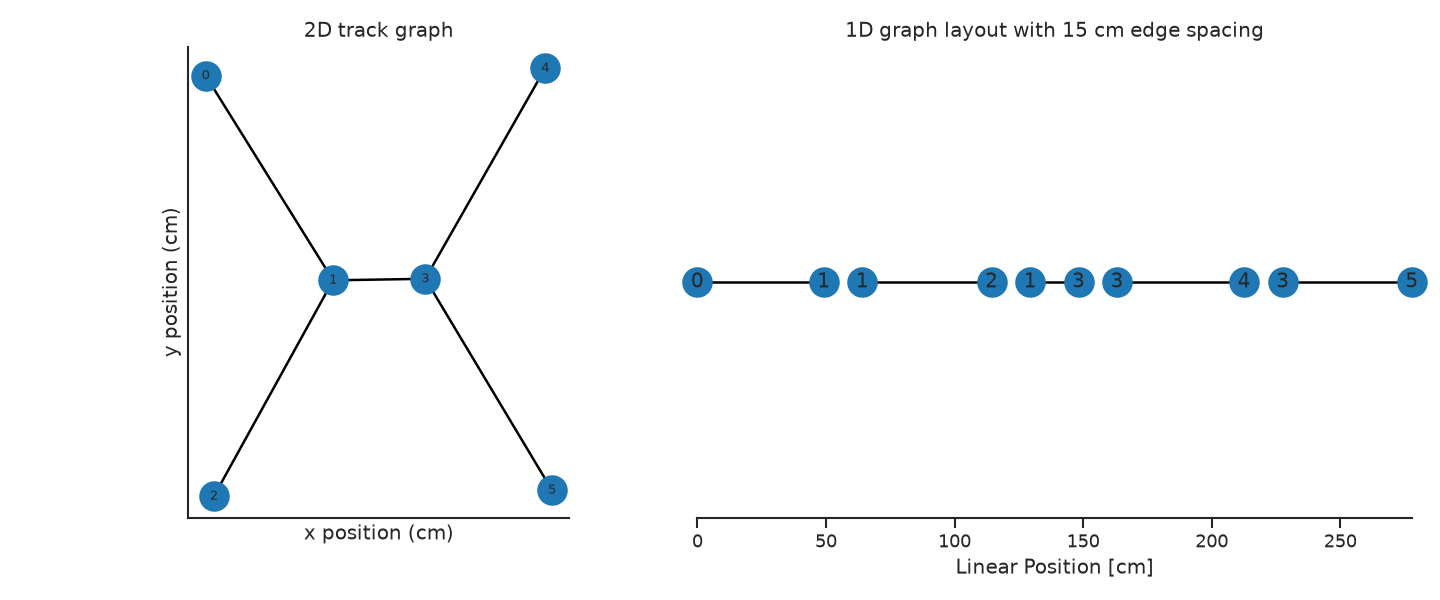

In [11]:
track_graph = make_track_graph(node_positions, edges)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
plot_track_graph(track_graph, ax=axes[0])
axes[0].set_aspect('equal', adjustable='box')
axes[0].set_xlabel('x position (cm)')
axes[0].set_ylabel('y position (cm)')
axes[0].set_title('2D track graph')

plot_graph_as_1D(track_graph, edge_spacing=15.0, ax=axes[1])
axes[1].set_title('1D graph layout with 15 cm edge spacing')

plt.tight_layout()
plt.show()


## 6. Save the graph

Save the graph in the same coordinate system as the NWB file.

In [12]:
graph_spec = {
    'asset_path': asset_path,
    'coordinate_unit': position_series.unit,
    'reference_frame': position_series.reference_frame,
    'node_positions': [list(map(float, pos)) for pos in node_positions],
    'edges': [list(map(int, edge)) for edge in edges],
}

graph_spec_path = Path('lovelace_track_graph_xmaze.json')
graph_spec_path.write_text(json.dumps(graph_spec, indent=2))
print(f'Saved {graph_spec_path.resolve()}')


Saved /home/labuser/Documents/camp2026/lovelace_track_graph_xmaze.json
